In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


# Fig 1: Whole brain electrodes map to the pial surface

In [3]:
task = [
    'PhonemeSequence',
    'SentenceRep',
    'LexicalDelay',
    'LexicalNoDelay',
    'PictureNaming',
]
ref='bipolar'

stats_paths = []
stats_paths.extend(
    BIDSPath(
        root=f'../results/{t}({ref})',
        datatype='HGA',
        suffix='coord',
        check=False,
    ).match()
    for t in task
)

stats_paths = np.concatenate(stats_paths).tolist()

coords = []
for path in tqdm(stats_paths):
    df = pd.read_csv(path)
    coords.append(df)
    
coords = pd.concat(coords)

# rename INS to 'Insula'
coords.loc[coords.roi == 'INS', 'roi'] = 'Insula'

# combine HG to STG
coords.loc[coords.roi == 'HG', 'roi'] = 'STG'

# rename CG to Cingulate cortex
coords.loc[coords.roi == 'PrG', 'roi'] = 'SMC'
coords.loc[coords.roi == 'PoG', 'roi'] = 'SMC'
coords.loc[coords.roi == 'Subcentral', 'roi'] = 'SMC'

coords.head()

100%|██████████| 911/911 [00:02<00:00, 388.64it/s]


,channel,x,y,z,HGA,significant,subject,task,band,description,phase,label,roi,hemi
0,D0019_ROG1-2,20.731562,-95.433053,-4.406237,-0.041696,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R
1,D0019_ROG2-3,18.712896,-94.417750,6.523434,0.027467,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R
2,D0019_ROG3-4,17.039880,-94.822626,17.317047,0.047800,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R
3,D0019_ROG4-5,16.298644,-91.860079,29.446276,0.044848,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_G_occipital_sup,sOccG,R
4,D0019_ROG5-6,13.397947,-84.402838,39.447554,0.003595,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


2026-01-11 11:11:42.718 (  28.921s) [    7FADC0A4F440]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-11 11:11:43.138 (  29.341s) [    7FADC0A4F440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x67241e0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-11 11:11:43.590 (  29.793s) [    7FADC0A4F440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x6862f30): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D en

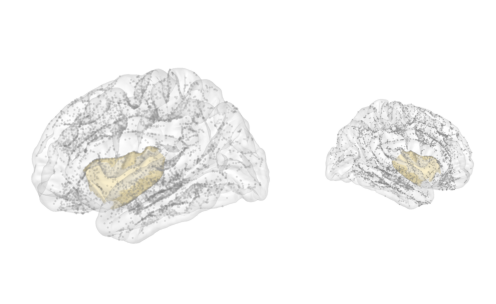

In [4]:
coords_unique = coords.drop_duplicates(subset=['channel'])

from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree

# 读取labels用于过滤电极
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# 创建Brain对象 - 使用pial表面
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)

cord = coords_unique[['x', 'y', 'z']].values

mask_lh = cord[:, 0] < 0  # x < 0 为左半球
mask_rh = cord[:, 0] > 0  # x > 0 为右半球

# 加载pial表面数据用于投射
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_coords_pial, lh_faces = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_coords_pial, rh_faces = mne.read_surface(rh_pial_path)
rh_tree = cKDTree(rh_coords_pial)

# 统一电极颜色
electrode_color = 'gray'

# 处理左半球电极 - 投射到表面
if mask_lh.any():
    lh_cord = cord[mask_lh]
    # 找到每个电极最近的大脑表面顶点
    _, lh_indices = lh_tree.query(lh_cord)
    
    # 获取投射后的坐标（表面上的坐标）
    lh_projected_coords = lh_coords_pial[lh_indices]
    
    # 过滤：只保留在大脑表面附近的电极
    valid_mask = np.zeros(len(lh_cord), dtype=bool)
    for i, idx in enumerate(lh_indices):
        # 检查是否在任何label内
        for lab in labels:
            if lab.hemi == 'lh' and idx in lab.vertices:
                valid_mask[i] = True
                break
    
    # 绘制投射到表面的电极
    if valid_mask.any():
        cloud = pv.PolyData(lh_projected_coords[valid_mask])  # 使用投射后的坐标
        lh_brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=10,
            color=electrode_color,
            lighting=False,
            smooth_shading=False,
            opacity=0.3,
        )

# 处理右半球电极 - 投射到表面
if mask_rh.any():
    rh_cord = cord[mask_rh]
    # 找到每个电极最近的大脑表面顶点
    _, rh_indices = rh_tree.query(rh_cord)
    
    # 获取投射后的坐标（表面上的坐标）
    rh_projected_coords = rh_coords_pial[rh_indices]
    
    # 过滤：只保留在大脑表面附近的电极
    valid_mask = np.zeros(len(rh_cord), dtype=bool)
    for i, idx in enumerate(rh_indices):
        # 检查是否在任何label内
        for lab in labels:
            if lab.hemi == 'rh' and idx in lab.vertices:
                valid_mask[i] = True
                break
    
    # 绘制投射到表面的电极
    if valid_mask.any():
        cloud = pv.PolyData(rh_projected_coords[valid_mask])  # 使用投射后的坐标
        rh_brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=10,
            color=electrode_color,
            lighting=False,
            smooth_shading=False,
            opacity=0.5,
        )


# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [3, 1]})
plt.subplots_adjust(wspace=-0.5)
ax1.imshow(lh_brain.screenshot(mode="rgb"))
ax1.axis("off")

ax2.imshow(rh_brain.screenshot(mode="rgb"))
ax2.axis("off")

# 关闭 Brain 对象
lh_brain.close()
rh_brain.close()

plt.tight_layout()
# plt.savefig('../img/fig1/fig1_all_electrodes_projected.svg', dpi=300, bbox_inches='tight')
plt.show()

# Plot Anterioro-posterior insula electrodes

In [5]:
# Insula region classification function and visualization
def classify_insula_ap(coords_df, y_threshold=0):
    """
    Classify insula electrodes into AIC (anterior insula cortex) and PIC (posterior insula cortex)
    
    Classification scheme:
    AIC (red team): 
      - All G_insular_short (regardless of coordinates)
      - All S_circular_insula_ant (regardless of coordinates)  
      - All S_circular_insula_sup with Y > 0
      - All S_circular_insula_inf with Y > 0
    
    PIC (blue team):
      - All G_Ins_lg_and_S_cent_ins (regardless of coordinates)
      - All S_circular_insula_sup with Y <= 0
      - All S_circular_insula_inf with Y <= 0
    """
    # Copy data to avoid modifying original data
    coords_classified = coords_df.copy()
    
    # Initialize new classification
    coords_classified['insula_region'] = coords_classified['roi']
    
    # Only process insula electrodes
    insula_mask = coords_classified['roi'] == 'Insula'
    
    # AIC classification conditions
    aic_conditions = (
        (coords_classified['label'].str.contains('G_insular_short')) |
        (coords_classified['label'].str.contains('S_circular_insula_ant')) |
        ((coords_classified['label'].str.contains('S_circular_insula_sup')) & (coords_classified['y'] > y_threshold)) |
        ((coords_classified['label'].str.contains('S_circular_insula_inf')) & (coords_classified['y'] > y_threshold))
    )
    
    # PIC classification conditions  
    pic_conditions = (
        (coords_classified['label'].str.contains('G_Ins_lg_and_S_cent_ins')) |
        ((coords_classified['label'].str.contains('S_circular_insula_sup')) & (coords_classified['y'] <= y_threshold)) |
        ((coords_classified['label'].str.contains('S_circular_insula_inf')) & (coords_classified['y'] <= y_threshold))
    )
    
    # Apply classification
    coords_classified.loc[insula_mask & aic_conditions, 'roi'] = 'AIC'
    coords_classified.loc[insula_mask & pic_conditions, 'roi'] = 'PIC'
    
    return coords_classified

# Apply classification function
coords_ap = classify_insula_ap(coords)

# Statistical results
print(f"AIC electrode count: {len(coords_ap[coords_ap['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(coords_ap[coords_ap['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = coords_ap[coords_ap['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
coords_ap.head()

AIC electrode count: 1572
PIC electrode count: 1664


,channel,x,y,z,HGA,significant,subject,task,band,description,phase,label,roi,hemi,insula_region
0,D0019_ROG1-2,20.731562,-95.433053,-4.406237,-0.041696,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R,OPC
1,D0019_ROG2-3,18.712896,-94.417750,6.523434,0.027467,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_Pole_occipital,OPC,R,OPC
2,D0019_ROG3-4,17.039880,-94.822626,17.317047,0.047800,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R,Unknown
3,D0019_ROG4-5,16.298644,-91.860079,29.446276,0.044848,False,D0019,PhonemeSequence,highgamma,Repeat,Go,ctx_rh_G_occipital_sup,sOccG,R,sOccG
4,D0019_ROG5-6,13.397947,-84.402838,39.447554,0.003595,False,D0019,PhonemeSequence,highgamma,Repeat,Go,Unknown,Unknown,R,Unknown


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot


   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-11 11:20:39.242 ( 565.445s) [    7FADC0A4F440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x23691f70): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-11 11:20:39.322 ( 565.525s) [    7FADC0A4F440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x23691f70): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

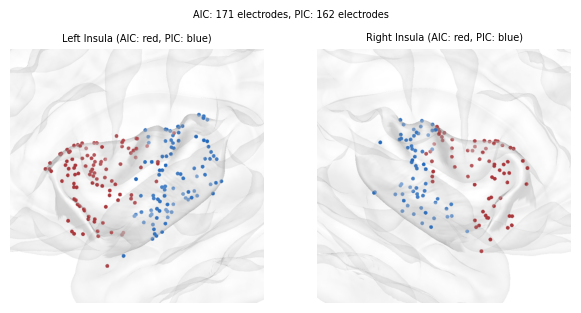

In [12]:
# 3D Brain with AIC/PIC分区显示 - Electrodes projected to surface
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree

# 读取aparc.a2009s labels
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# Insula相关的labels (aparc.a2009s)
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins', 
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']

# 加载pial表面用于投影
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# 创建左右半球Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="pial",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(800, 800)
)

# 计算insula区域的中心点
def get_insula_center(labels, hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        insula_coords = pial_coords[vertices]
        return insula_coords.mean(axis=0)
    return None

lh_insula_center = get_insula_center(labels, 'lh', lh_pial_coords)
rh_insula_center = get_insula_center(labels, 'rh', rh_pial_coords)

# 添加insula labels (高亮显示)
for lab in labels:
    if any(pattern in lab.name for pattern in insula_patterns):
        if lab.hemi == 'lh':
            lh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
        elif lab.hemi == 'rh':
            rh_brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)

# 获取分区后的insula电极 (使用修改后的roi列)
coords_unique_ap = coords_ap[coords_ap.roi.isin(['AIC', 'PIC'])].drop_duplicates(subset=['channel'])
cord = coords_unique_ap[['x', 'y', 'z']].values
regions = coords_unique_ap['roi'].values

# 分离左右半球电极
mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

# 定义颜色
aic_color = red
pic_color = blue

# 添加左半球电极（投影到表面）
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_regions = regions[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_proj = lh_pial_coords[lh_indices]
    
    # 分别添加AIC和PIC电极
    for region, color in [('AIC', aic_color), ('PIC', pic_color)]:
        region_mask = lh_regions == region
        if region_mask.any():
            cloud = pv.PolyData(lh_cord_proj[region_mask])
            lh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=12,
                color=color,
                lighting=False,
            )

# 添加右半球电极（投影到表面）
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_regions = regions[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_proj = rh_pial_coords[rh_indices]
    
    # 分别添加AIC和PIC电极
    for region, color in [('AIC', aic_color), ('PIC', pic_color)]:
        region_mask = rh_regions == region
        if region_mask.any():
            cloud = pv.PolyData(rh_cord_proj[region_mask])
            rh_brain._renderer.plotter.add_mesh(
                cloud,
                render_points_as_spheres=True,
                point_size=12,
                color=color,
                lighting=False,
            )

# 设置视角 - 聚焦在insula中心
lh_brain.show_view(azimuth=180, elevation=90, distance=180, 
                   focalpoint=lh_insula_center)
rh_brain.show_view(azimuth=0, elevation=90, distance=180, 
                   focalpoint=rh_insula_center)

# 截图并显示
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))

axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Insula (AIC: red, PIC: blue)", fontsize=fontsize)

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Insula (AIC: red, PIC: blue)", fontsize=fontsize)

# 添加统计信息
aic_count = len(coords_unique_ap[coords_unique_ap['roi'] == 'AIC'])
pic_count = len(coords_unique_ap[coords_unique_ap['roi'] == 'PIC'])
plt.suptitle(f"AIC: {aic_count} electrodes, PIC: {pic_count} electrodes", fontsize=fontsize)

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.show()

# TFR on the representation electrode

In [17]:
bids_root = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'

In [16]:
subject = 'D0088'
coords_ap[(coords_ap.subject==subject) &
          (coords_ap.roi=='AIC')].channel.unique()

array(['D0088_LAI1-2', 'D0088_LAI5-6', 'D0088_LAI6-7'], dtype=object)

In [ ]:
# load 


description = 'production'

tfr_path = BIDSPath(
    root=os.path.join(bids_root, 'derivatives', 'tfr'),
    datatype='bipolar',
    suffix='tfr',
    extension='.h5',
    check=False
)

tfr_path = tfr_path.copy().update(subject=subject, description=description)
tfr = mne.time_frequency.read_tfrs(
    tfr_path.fpath,
    verbose=False
)

stats_path = tfr_path.copy().update(
            suffix='stats',
        )

stats = h5py.File(stats_path.fpath, 'r')
mask = stats['mask'][()]
pvals = stats['pvals'][()]
stats.close()

idx = tfr.ch_names.index(pickchannels[0])
tfr = tfr.pick(pickchannels)